In [1]:
import sys
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_cleaning import clean_nonprofit_data, standardize_and_stack_financials, enrich_with_financials
import plotly.express as px

### Ingesting and Cleaning IRS Business Master File to Identify Summary Metrics


* Using helper functions from data_cleaning.py to automatically filter upon nonprofits in Virginia, using 503c status.

* Identifying key summary metrics, such as the number of 503(c) nonprofits in the state of Virginia.

In [2]:

df_bmf = clean_nonprofit_data('../data/eo_va.csv')
print(f"Total Charitable Nonprofits: {len(df_bmf)}")

Total Charitable Nonprofits: 44634


### Ingesting IRS990 Data to Incorporate Key Financial Information

Combining the IRS Business Masterfile with the IRS990 dataset (using helper function) to access line-by-line financial data

In [3]:
df_finance_master = standardize_and_stack_financials(
    core_path='../data/23eoextract990.csv',
    ez_path='../data/23eoextractez.csv',
    pf_path='../data/23eoextract990pf.csv'
)

masterfile = enrich_with_financials(df_bmf, df_finance_master)

In [4]:
print(f"Total Organizations Kept: {len(masterfile)}")

Total Organizations Kept: 44634


### Calculating Metrics Related to the Total Economic Footprint of Nonprofits and Workforce Total

> **Note on Data Freshness:** > Because the IRS Business Master File (BMF) updates every 15 days while 990 Extracts are released annually, there is a natural temporal "drift." The high coverage of the state's total salary (89% matched) despite the 55% organization-count gap proves that our dataset successfully captures the high-impact "Economic Engines" of Virginia's nonprofit sector.

In [5]:
# Calculate total economic footprint
total_salary_billions = masterfile['Total_Comp_Unified'].sum() / 1e9

print(f"Total Virginia Nonprofit Salary Footprint: ${total_salary_billions:.3f} Billion")

# Check the workforce total as well
total_employees = masterfile['Employee_Count_Unified'].sum()
print(f"Total Reported Employees: {total_employees:,.0f}")

Total Virginia Nonprofit Salary Footprint: $23.140 Billion
Total Reported Employees: 428,023


In [6]:
# Create a flag to identify temporal alignment
masterfile['Data_Status'] = 'Financials Missing (Likely New/Small)'

# Checking for matching the extract year (2023)
masterfile.loc[masterfile['TAX_PERIOD'].astype(str).str.startswith('2023'), 'Data_Status'] = 'Matched (2023)'

# Check  fornewer tax period (2024+)
masterfile.loc[masterfile['TAX_PERIOD'].astype(str).str.startswith('2024'), 'Data_Status'] = 'Matched (Recent)'

# Now, visualize the 'Health' of your data
print(masterfile['Data_Status'].value_counts(normalize=True) * 100)

Data_Status
Financials Missing (Likely New/Small)    55.551821
Matched (Recent)                         40.702155
Matched (2023)                            3.746023
Name: proportion, dtype: float64


### Visualizing Nonprofit Economic Analysis by Sector

In [7]:
# Extracting the first letter from BMF NTEE code to match with NTEE Major categories description

masterfile['NTEE_Letter']=masterfile['NTEE_CD'].str[0].str.upper()
mapped_csv=pd.read_csv('../data/ntee_simple.csv')

masterfile=pd.merge(masterfile,mapped_csv,left_on='NTEE_Letter',right_on='Code',how='left')
masterfile['Category']=masterfile['Category'].fillna('Unknown')


Performing data aggregation (by Category and Organization Count) for upcoming visualiztions

In [8]:
sector_stats = masterfile.groupby('Category').agg({
    'EIN': 'count',
    'Total_Comp_Unified': 'sum'
}).reset_index()

sector_stats.columns = ['Sector', 'Org_Count', 'Total_Salary']
sector_stats['Total_Salary_Billions'] = sector_stats['Total_Salary'] / 1e9

count_sorted = sector_stats.sort_values('Org_Count', ascending=False)
salary_sorted = sector_stats.sort_values('Total_Salary_Billions', ascending=False)

Developing Visualization for Nonprofit Counts by Sector

/var/folders/09/89r30_ms6xdcd7znk61plqgr0000gn/T/ipykernel_64545/423198469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


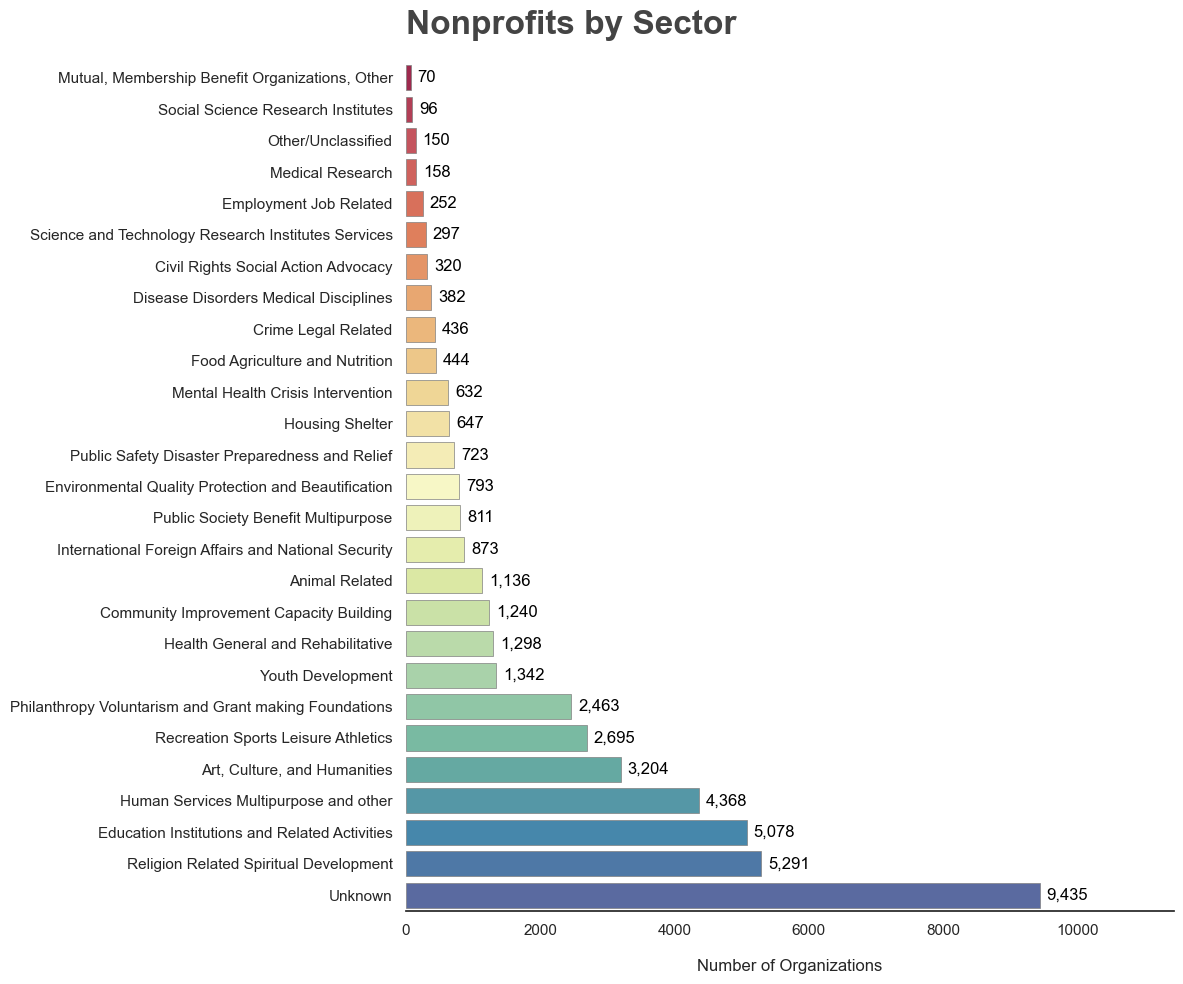

In [34]:
plot_data = count_sorted.sort_values('Org_Count', ascending=True)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 10))

# Creating horizontal bar plot for report
bars = sns.barplot(
    data=plot_data, 
    x='Org_Count', 
    y='Sector', 
    palette='Spectral', 
    edgecolor='gray',
    linewidth=0.5
)

# Adding the data labels at the end of each bar
for i, v in enumerate(plot_data['Org_Count']):
    ax.text(v + 100, i, f'{int(v):,}', color='black', va='center', fontweight='medium')

ax.set_title('Nonprofits by Sector', fontsize=24, loc='left', pad=20, color='#444444',fontweight='bold')
ax.set_xlabel('Number of Organizations', fontsize=12, labelpad=15)
ax.set_ylabel('') 

sns.despine(left=True, bottom=False)
ax.set_xlim(0, plot_data['Org_Count'].max() + 2000)

plt.tight_layout()
plt.savefig(
    os.path.join('../results_and_visualizations', 'nonprofit_diversity_count.png'), 
    dpi=300,             
    bbox_inches='tight', 
    transparent=False,   
    facecolor='white'    
)
plt.show()

In [31]:
bins = [0, 100000, 250000, 1000000, 2000000, 5000000, 10000000, 1e12]
labels = [
    '$1 – $100,000', 
    '$100,000 – $250,000', 
    '$250,000 – $1M', 
    '$1M – $2M', 
    '$2M – $5M', 
    '$5M – $10M', 
    '$10M+'
]
cne_colors = [
    "#72BDC0", 
    "#3792A4", 
    "#0E5859", 
    '#3F6F8E', 
    '#5FA547', 
    '#A4B6C3', 
    '#8C8C8C'  
]


# Creating the 'Revenue_Bucket' column
masterfile['Revenue_Bucket'] = pd.cut(masterfile['REVENUE_AMT'], bins=bins, labels=labels)

revenue_counts = masterfile['Revenue_Bucket'].value_counts().sort_index()

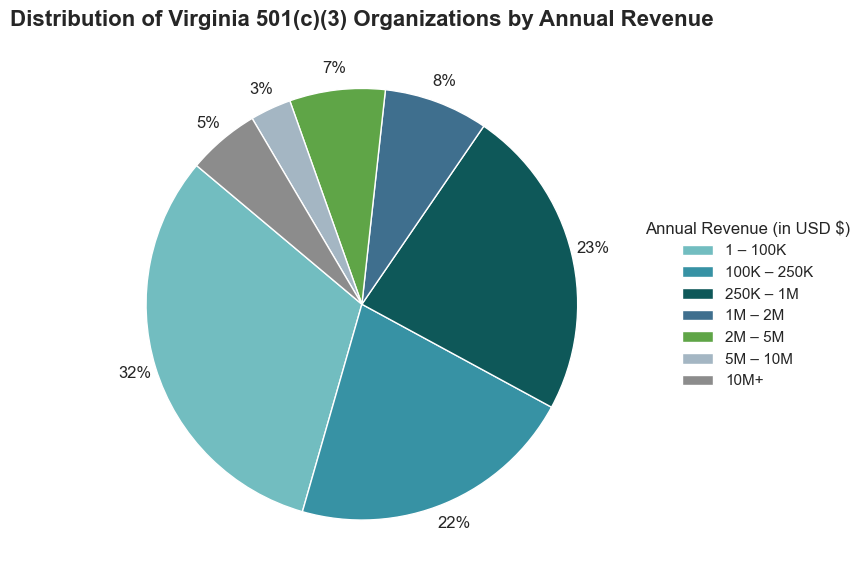

In [37]:
clean_labels = [
    '1 – 100K', 
    '100K – 250K', 
    '250K – 1M', 
    '1M – 2M', 
    '2M – 5M', 
    '5M – 10M', 
    '10M+'
]

fig, ax = plt.subplots(figsize=(8, 6))

patches, texts, autotexts = ax.pie(
    revenue_counts, 
    autopct='%1.0f%%', 
    startangle=140, 
    colors=cne_colors,
    pctdistance=1.1
)

ax.legend(
    patches, 
    clean_labels, 
    title="Annual Revenue (in USD $)", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=False
)

plt.title('Distribution of Virginia 501(c)(3) Organizations by Annual Revenue', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('../results_and_visualizations', 'Distribution_of_Virginia_501(c)(3)_Organizations_by_Annual_Revenue.png'), 
    dpi=300,             
    bbox_inches='tight', 
    transparent=False,   
    facecolor='white'    
)
plt.show()